# Librerías

In [1]:
import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import SimpleITK as sitk
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Configuración

In [2]:
DATA_PATH = "data"

ANNOTATIONS_PATH = os.path.join(DATA_PATH, "annotations.csv")
CANDIDATES_PATH = os.path.join(DATA_PATH, "candidates.csv")

VALIDATION_LIST = "splits/validation.txt"

OUTPUT_DIR = "dataset_validation"

POSITIVE_DIR = os.path.join(OUTPUT_DIR,"positive")
NEGATIVE_DIR = os.path.join( OUTPUT_DIR,"negative")

os.makedirs(POSITIVE_DIR, exist_ok=True)
os.makedirs(NEGATIVE_DIR, exist_ok=True)

PATCH_SIZE = 64

OFFSET_XY_MM = 8
OFFSET_Z_MM = 4

N_OFFSETS = 5

NEGATIVE_RATIO = 3 * N_OFFSETS

DISTANCIA_MAX_MM = 2

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# Leer archivos

In [3]:
annotations = pd.read_csv(ANNOTATIONS_PATH)
candidates = pd.read_csv(CANDIDATES_PATH)
with open(VALIDATION_LIST) as f:
    validation_ct = set(
        line.strip()
        for line in f
    )
print("Annotations:", len(annotations))
print("Candidates:", len(candidates))
print("CT Validation:", len(validation_ct))

Annotations: 1186
Candidates: 551065
CT Validation: 133


## Filtrar solamente validation

In [4]:
annotations_validation = annotations[
    annotations["seriesuid"].isin(validation_ct)
].copy()

candidates_validation = candidates[
    candidates["seriesuid"].isin(validation_ct)
].copy()

print("Annotations validation:", len(annotations_validation))
print("Candidates validation:", len(candidates_validation))

Annotations validation: 179
Candidates validation: 79764


## Construcción de positivos

In [5]:
candidates_positive = candidates_validation[
    candidates_validation["class"] == 1
].copy()

print(len(candidates_positive))

197


## Eliminar candidatos duplicados

In [6]:
indices_eliminar = []

for idx, row in candidates_positive.iterrows():

    nodulos = annotations_validation[
        annotations_validation["seriesuid"] == row["seriesuid"]
    ]

    if len(nodulos) == 0:
        continue

    distancias = np.sqrt(

        (nodulos.coordX-row.coordX)**2 +

        (nodulos.coordY-row.coordY)**2 +

        (nodulos.coordZ-row.coordZ)**2

    )

    if distancias.min() <= DISTANCIA_MAX_MM:

        indices_eliminar.append(idx)

candidates_positive = candidates_positive.drop(indices_eliminar)

print("Candidates positivos finales:",len(candidates_positive))

Candidates positivos finales: 56


## Unir annotations + candidates

In [7]:
annotations_validation["source"] = "annotation"
candidates_positive["source"] = "candidate"
candidates_positive["diameter_mm"] = np.nan

positive_df = pd.concat(
    [
        annotations_validation[[
            "seriesuid",
            "coordX",
            "coordY",
            "coordZ",
            "diameter_mm",
            "source"
        ]],

        candidates_positive[[
            "seriesuid",
            "coordX",
            "coordY",
            "coordZ",
            "diameter_mm",
            "source"
        ]]
    ],
    ignore_index=True
)

print("Positivos finales:",len(positive_df))

Positivos finales: 235


# Construcción de negativos

In [8]:
ct_con_nodulo = set(
    annotations_validation.seriesuid.unique()
)

negative_df = candidates_validation[
    (candidates_validation["class"]==0)
    &
    (~candidates_validation["seriesuid"].isin(ct_con_nodulo))
].copy()

print(len(negative_df))

26080


## Balance 3:1

In [9]:
n_positive = len(positive_df)
n_negative = NEGATIVE_RATIO * n_positive

ct_sanas = negative_df["seriesuid"].unique()

print("CT sanas:", len(ct_sanas))

negativos_por_ct = int(
    np.ceil(
        n_negative / len(ct_sanas)
    )
)

print("Negativos por CT:", negativos_por_ct)

negative_balanceado = []

for ct in ct_sanas:

    candidatos_ct = negative_df[
        negative_df["seriesuid"] == ct
    ]

    n = min(
        len(candidatos_ct),
        negativos_por_ct
    )

    negative_balanceado.append(
        candidatos_ct.sample(
            n=n,
            random_state=42
        )
    )

negative_df = pd.concat(
    negative_balanceado,
    ignore_index=True
)

print("Negativos finales:", len(negative_df))

CT sanas: 43
Negativos por CT: 82
Negativos finales: 3509


In [10]:
print()

print("Positivos:",len(positive_df))

print("Negativos:",len(negative_df))

print("Ratio:",

      len(negative_df)/len(positive_df)
)


Positivos: 235
Negativos: 3509
Ratio: 14.931914893617021


## Buscar automáticamente la tomografía

In [11]:
ct_paths = {}

for subset in range(10):

    folder = os.path.join(
        DATA_PATH,
        f"subset{subset}"
    )

    for file in os.listdir(folder):

        if file.endswith(".mhd"):

            seriesuid = file.replace(".mhd","")

            ct_paths[seriesuid] = os.path.join(
                folder,
                file
            )

print(len(ct_paths))

888


# Extraer patch

In [12]:
def extract_patch(volume, center, patch_size=64):
    z, y, x = center
    half = patch_size // 2
    
    # Calcular los límites del parche
    z_min = max(0, z - half)
    z_max = min(volume.shape[0], z + half)
    y_min = max(0, y - half)
    y_max = min(volume.shape[1], y + half)
    x_min = max(0, x - half)
    x_max = min(volume.shape[2], x + half)
    
    # Extraer la porción válida
    patch = volume[z_min:z_max, y_min:y_max, x_min:x_max]
    
    # Si la porción es más pequeña que el tamaño deseado, rellenar con ceros
    if patch.shape != (patch_size, patch_size, patch_size):
        temp = np.zeros((patch_size, patch_size, patch_size), dtype=np.float32)
        # Calcular dónde poner el parche dentro del arreglo temporal
        z_offset = half - (z - z_min)  # o simplemente usar slicing directo:
        # Para hacerlo simple:
        temp[
            (half - (z - z_min)):(half - (z - z_min) + patch.shape[0]),
            (half - (y - y_min)):(half - (y - y_min) + patch.shape[1]),
            (half - (x - x_min)):(half - (x - x_min) + patch.shape[2])
        ] = patch
        patch = temp
        
    return patch

## Random Offset

In [13]:
def random_offset(voxel, spacing):

    z, y, x = voxel

    oz = random.randint(
        -round(OFFSET_Z_MM / spacing[2]),
         round(OFFSET_Z_MM / spacing[2])
    )

    oy = random.randint(
        -round(OFFSET_XY_MM / spacing[1]),
         round(OFFSET_XY_MM / spacing[1])
    )

    ox = random.randint(
        -round(OFFSET_XY_MM / spacing[0]),
         round(OFFSET_XY_MM / spacing[0])
    )

    return (
        z + oz,
        y + oy,
        x + ox
    )

# Extraer patches positivos

In [14]:
dataset_info = []
patch_id = 0
seriesuid_list = positive_df["seriesuid"].unique()

In [15]:
def preprocess(volume):

    volume = np.clip(volume,-1000,400)
    volume = (volume + 1000) / 1400

    return volume.astype(np.float32)

In [16]:
vacios_descartados = 0
for seriesuid in tqdm(seriesuid_list):

    # Buscar la tomografía
    mhd_path = ct_paths.get(seriesuid)

    if mhd_path is None:
        continue

    # Leer CT una sola vez
    sitk_img = sitk.ReadImage(mhd_path)

    volume = sitk.GetArrayFromImage(sitk_img).astype(np.float32)

    # Windowing
    volume = preprocess(volume)

    origin = sitk_img.GetOrigin()
    spacing = sitk_img.GetSpacing()

    # Positivos de esta CT
    positivos_ct = positive_df[
        positive_df["seriesuid"] == seriesuid
    ]

    for _, row in positivos_ct.iterrows():

        voxelX = int(
            (row.coordX - origin[0]) / spacing[0]
        )

        voxelY = int(
            (row.coordY - origin[1]) / spacing[1]
        )

        voxelZ = int(
            (row.coordZ - origin[2]) / spacing[2]
        )

        # Generar varios offsets
        for _ in range(N_OFFSETS):

            centro = random_offset(
                (voxelZ, voxelY, voxelX),
                spacing
            )
            
            # Dentro del bucle de positivos y negativos, después de calcular centro:
            half = PATCH_SIZE // 2
            centro = (
                np.clip(centro[0], half, volume.shape[0] - half - 1),
                np.clip(centro[1], half, volume.shape[1] - half - 1),
                np.clip(centro[2], half, volume.shape[2] - half - 1)
            )

            patch = extract_patch(
                volume,
                centro,
                PATCH_SIZE
            )

            if np.all(patch == 0):
                vacios_descartados += 1
                continue

            filename = f"patch_{patch_id:06d}.npy"

            np.save(
                os.path.join(
                    POSITIVE_DIR,
                    filename
                ),
                patch
            )

            dataset_info.append({
                "patch": f"positive/{filename}",
                "seriesuid": seriesuid,
                "label": 1,
                "source": row.source,
                "diameter_mm": row.diameter_mm,
                "centro_z": centro[0],
                "centro_y": centro[1],
                "centro_x": centro[2],
                "voxelZ_original": voxelZ,
                "voxelY_original": voxelY,
                "voxelX_original": voxelX
            })

            patch_id += 1

100%|██████████| 90/90 [01:06<00:00,  1.35it/s]


In [17]:
negative_seriesuid = negative_df["seriesuid"].unique()
vacios_descartados = 0
for seriesuid in tqdm(negative_seriesuid):

    # Buscar la tomografía
    mhd_path = ct_paths.get(seriesuid)

    if mhd_path is None:
        continue

    # Leer CT una sola vez
    sitk_img = sitk.ReadImage(mhd_path)

    volume = sitk.GetArrayFromImage(sitk_img).astype(np.float32)

    # Windowing
    volume = preprocess(volume)

    origin = sitk_img.GetOrigin()
    spacing = sitk_img.GetSpacing()

    # Todos los negativos de esta CT
    negativos_ct = negative_df[
        negative_df["seriesuid"] == seriesuid
    ]

    for _, row in negativos_ct.iterrows():

        voxelX = int(
            (row.coordX - origin[0]) / spacing[0]
        )

        voxelY = int(
            (row.coordY - origin[1]) / spacing[1]
        )

        voxelZ = int(
            (row.coordZ - origin[2]) / spacing[2]
        )

        centro = random_offset(
            (voxelZ, voxelY, voxelX),
            spacing
        )

        # Dentro del bucle de positivos y negativos, después de calcular centro:
        half = PATCH_SIZE // 2
        centro = (
            np.clip(centro[0], half, volume.shape[0] - half - 1),
            np.clip(centro[1], half, volume.shape[1] - half - 1),
            np.clip(centro[2], half, volume.shape[2] - half - 1)
        )

        patch = extract_patch(
            volume,
            centro,
            PATCH_SIZE
        )

        if np.all(patch == 0):
            vacios_descartados += 1
            continue

        filename = f"patch_{patch_id:06d}.npy"

        np.save(
            os.path.join(
                NEGATIVE_DIR,
                filename
            ),
            patch
        )

        dataset_info.append({
            "patch": f"negative/{filename}",
            "seriesuid": seriesuid,
            "label": 0,
            "source": "candidate",
            "diameter_mm": np.nan
        })

        patch_id += 1

100%|██████████| 43/43 [00:52<00:00,  1.23s/it]


In [18]:
dataset_validation = pd.DataFrame(dataset_info)

dataset_validation.to_csv(
    "dataset_validation.csv",
    index=False
)

print("DATASET VALIDATION CREADO")

print("Total patches:", len(dataset_validation))

print(dataset_validation["label"].value_counts())

print(dataset_validation["source"].value_counts())

DATASET VALIDATION CREADO
Total patches: 4597
label
0    3427
1    1170
Name: count, dtype: int64
source
candidate     3707
annotation     890
Name: count, dtype: int64


# Validar

In [19]:
import numpy as np
import os

patch = np.load(
    os.path.join(
        POSITIVE_DIR,
        os.listdir(POSITIVE_DIR)[0]
    )
)

print(patch.shape)

(64, 64, 64)


In [20]:
print(patch.min())
print(patch.max())

0.0
1.0


In [21]:
(volume+1000)/1400

array([[[0.71428573, 0.71428573, 0.71428573, ..., 0.71428573,
         0.71428573, 0.71428573],
        [0.71428573, 0.71428573, 0.71428573, ..., 0.71428573,
         0.71428573, 0.71428573],
        [0.71428573, 0.71428573, 0.71428573, ..., 0.71428573,
         0.71428573, 0.71428573],
        ...,
        [0.71428573, 0.71428573, 0.71428573, ..., 0.71428573,
         0.71428573, 0.71428573],
        [0.71428573, 0.71428573, 0.71428573, ..., 0.71428573,
         0.71428573, 0.71428573],
        [0.71428573, 0.71428573, 0.71428573, ..., 0.71428573,
         0.71428573, 0.71428573]],

       [[0.71428573, 0.71428573, 0.71428573, ..., 0.71428573,
         0.71428573, 0.71428573],
        [0.71428573, 0.71428573, 0.71428573, ..., 0.71428573,
         0.71428573, 0.71428573],
        [0.71428573, 0.71428573, 0.71428573, ..., 0.71428573,
         0.71428573, 0.71428573],
        ...,
        [0.71428573, 0.71428573, 0.71428573, ..., 0.71428573,
         0.71428573, 0.71428573],
        [0.7

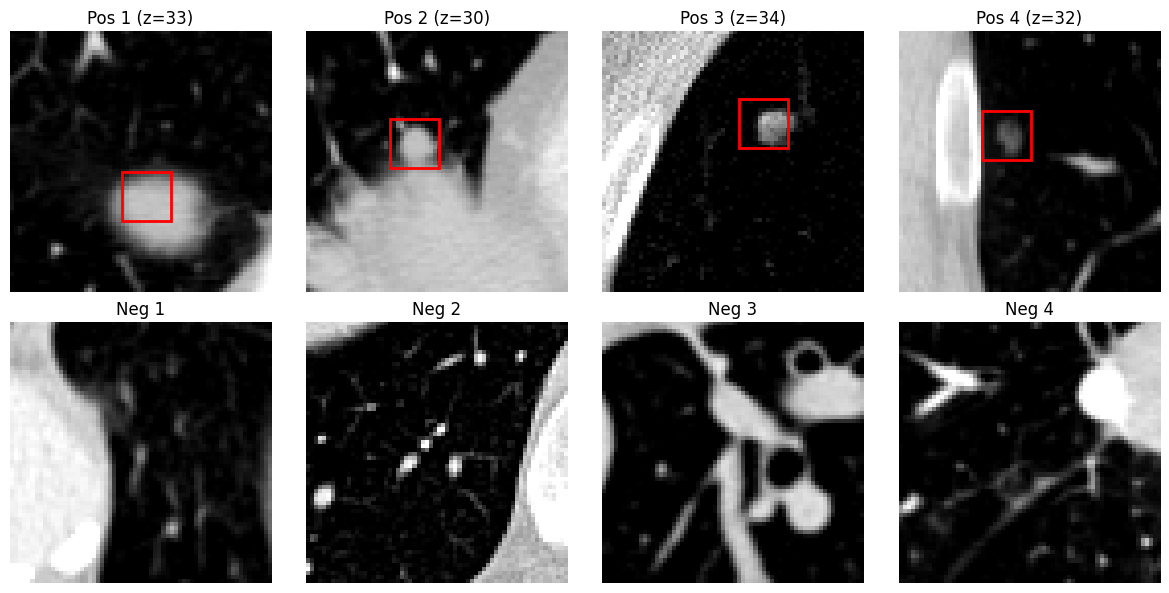

In [22]:
# Cargar el dataset_info
df = pd.read_csv("dataset_validation.csv")

# Filtrar positivos y negativos
pos_df = df[df['label'] == 1].copy()
neg_df = df[df['label'] == 0].copy()

# Seleccionar 4 aleatorios de cada clase
pos_muestras = pos_df.sample(4, random_state=42)
neg_muestras = neg_df.sample(4, random_state=42)

# Crear figura de 2 filas x 4 columnas
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# --- FILA Positivos ---
for i, (idx, row) in enumerate(pos_muestras.iterrows()):
    # Cargar el parche
    patch_path = os.path.join(OUTPUT_DIR, row['patch'])
    patch = np.load(patch_path)

    # Calcular posición del nódulo dentro del parche
    x_patch = row['voxelX_original'] - row['centro_x'] + 32
    y_patch = row['voxelY_original'] - row['centro_y'] + 32
    z_patch = row['voxelZ_original'] - row['centro_z'] + 32

    x_patch = int(np.clip(x_patch, 0, 63))
    y_patch = int(np.clip(y_patch, 0, 63))
    z_patch = int(np.clip(z_patch, 0, 63))

    # Diámetro en píxeles (si no tienes spacing, usar fijo)
    if 'spacing_x' in row and 'spacing_y' in row:
        diam_px_x = row['diameter_mm'] / row['spacing_x']
        diam_px_y = row['diameter_mm'] / row['spacing_y']
    else:
        diam_px_x = diam_px_y = 12

    # Mostrar el slice donde está el nódulo
    ax = axes[0, i]
    ax.imshow(patch[z_patch], cmap='gray', vmin=0.1, vmax=0.9)

    # Dibujar rectángulo y punto central
    rect = Rectangle((x_patch - diam_px_x/2, y_patch - diam_px_y/2),
                     diam_px_x, diam_px_y,
                     linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

    ax.set_title(f'Pos {i+1} (z={z_patch})')
    ax.axis('off')

# --- FILA Negativos ---
for i, (idx, row) in enumerate(neg_muestras.iterrows()):
    patch_path = os.path.join(OUTPUT_DIR, row['patch'])
    patch = np.load(patch_path)

    # Para negativos, mostramos el slice central (32)
    ax = axes[1, i]
    ax.imshow(patch[32], cmap='gray', vmin=0.1, vmax=0.9)
    ax.set_title(f'Neg {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [23]:
vacios = []

for file in os.listdir(POSITIVE_DIR):

    p = np.load(os.path.join(POSITIVE_DIR,file))

    if np.all(p == 0):
        vacios.append(file)

print(len(vacios))

0


In [24]:
vacios_neg = []

for file in os.listdir(NEGATIVE_DIR):

    p = np.load(os.path.join(NEGATIVE_DIR,file))

    if np.all(p == 0):
        vacios_neg.append(file)

print(len(vacios_neg))

0


# Estadísticas

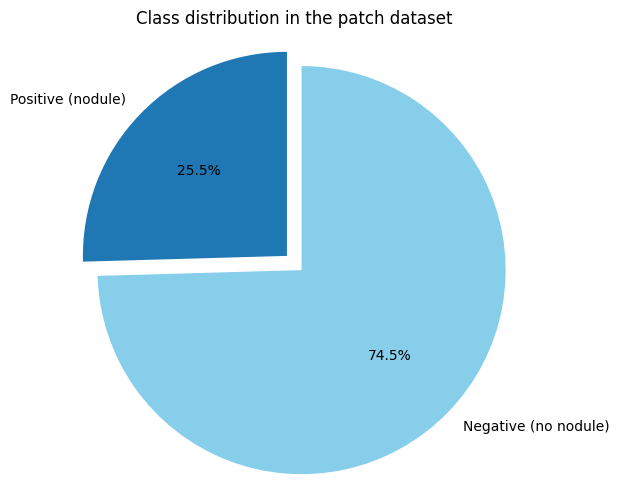

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("dataset_validation.csv")
counts = df['label'].value_counts()

# Asegurar el orden correcto
positivos = counts.get(1, 0)
negativos = counts.get(0, 0)
sizes = [positivos, negativos]
labels = ['Positive (nodule)', 'Negative (no nodule)']
colors = ['#1f77b4', '#87CEEB']
explode = (0.05, 0.05)

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, explode=explode)
plt.title('Class distribution in the patch dataset')
plt.axis('equal')
plt.show()

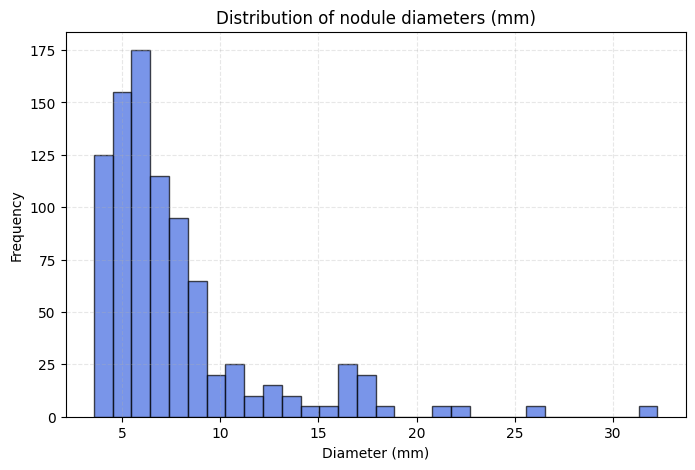

In [26]:
pos_df = df[df['label'] == 1]
plt.figure(figsize=(8,5))
plt.hist(pos_df['diameter_mm'], bins=30, color='royalblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of nodule diameters (mm)')
plt.xlabel('Diameter (mm)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

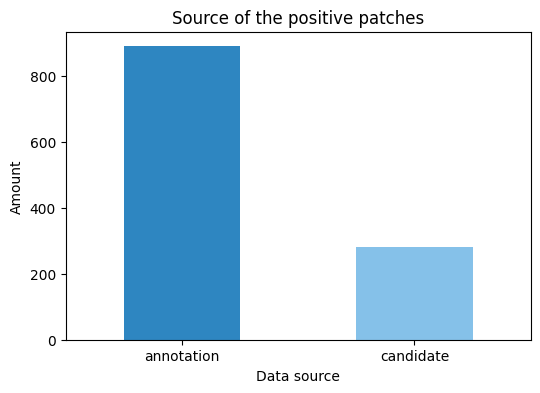

In [27]:
source_counts = pos_df['source'].value_counts()
plt.figure(figsize=(6,4))
source_counts.plot(kind='bar', color=['#2E86C1', '#85C1E9'])
plt.title('Source of the positive patches')
plt.xlabel('Data source')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.show()

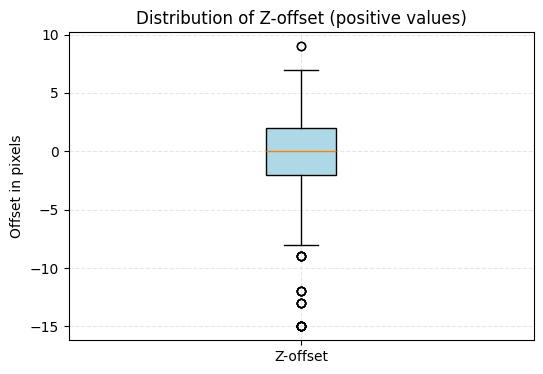

In [28]:
pos_df['offset_z'] = pos_df['centro_z'] - pos_df['voxelZ_original']
plt.figure(figsize=(6,4))
plt.boxplot(pos_df['offset_z'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
plt.title('Distribution of Z-offset (positive values)')
plt.ylabel('Offset in pixels')
plt.xticks([1], ['Z-offset'])
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

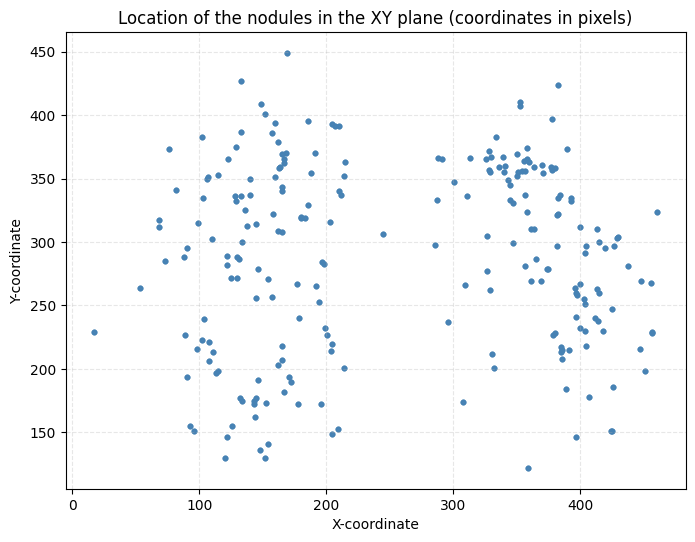

In [29]:
plt.figure(figsize=(8,6))
plt.scatter(pos_df['voxelX_original'], pos_df['voxelY_original'],
            c='steelblue', alpha=0.5, s=10)
plt.title('Location of the nodules in the XY plane (coordinates in pixels)')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.gca().set_aspect('equal')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()